<a href="https://colab.research.google.com/github/pedromurcia1232/Week5_1/blob/main/week5_hyperparameters_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Optimización e hiperparámetros en redes neuronales

**Objetivo:** comparar cómo cambia el entrenamiento de una red neuronal al ajustar hiperparámetros y al modificar el componente de optimización, usando un problema de clasificación binaria con `Breast Cancer Wisconsin Dataset`.

Este notebook cumple con los mínimos solicitados:
- modelo entrenable con evidencia por épocas,
- comparación válida entre configuraciones,
- registro de `loss` y `accuracy`,
- análisis en Markdown sobre estabilidad, velocidad de convergencia y hallazgos.


## 1. Plan de comparación

Se mantendrá constante la arquitectura base para que la comparación sea válida:

- Capa oculta: 32 neuronas, activación ReLU
- Salida: 1 neurona sigmoide
- Épocas: 30
- `batch_size`: 32
- Validación: 20% del conjunto de entrenamiento

Se compararán dos escenarios:

### Experimento A: hiperparámetro
- **Config A1:** Adam con `learning_rate = 0.001`
- **Config A2:** Adam con `learning_rate = 0.0005`

### Experimento B: optimización
- **Config B1:** Adam con `learning_rate = 0.001`
- **Config B2:** SGD con `learning_rate = 0.001`

> En cada experimento se modifica un solo factor y se conservan los demás elementos.

In [26]:
try:
    # Intentar importar TensorFlow para verificar si ya está instalado
    import tensorflow as tf
    print("TensorFlow ya está disponible:", tf.__version__)
except Exception:
    # Si no está instalado, instalar la versión más reciente de forma silenciosa
    !pip -q install tensorflow
    import tensorflow as tf
    print("TensorFlow instalado:", tf.__version__)

TensorFlow ya está disponible: 2.19.0


In [27]:
import numpy as np           # Biblioteca para operaciones numéricas y arreglos
import pandas as pd          # Biblioteca para manipulación de datos en tablas
import tensorflow as tf      # Framework principal de Deep Learning
from tensorflow import keras  # API de alto nivel para redes neuronales
from tensorflow.keras import layers # Módulo para definir las capas de la red
import matplotlib.pyplot as plt    # Biblioteca para visualización de gráficos

# Herramientas de Scikit-Learn para preparación de datos
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fijar semillas para asegurar que los resultados sean reproducibles
np.random.seed(7)
tf.random.set_seed(7)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [28]:
import pandas as pd
import numpy as np

# Configurar pandas para mostrar decimales en lugar de exponencial
pd.options.display.float_format = '{:.6f}'.format

# También ajustamos numpy para mantener consistencia en los arrays
np.set_printoptions(suppress=True, precision=6)

print("Configuración de visualización decimal activada.")

Configuración de visualización decimal activada.


In [29]:
# Cargar el dataset de cáncer de mama de Wisconsin
data = load_breast_cancer()
X, y = data.data, data.target # X: características, y: etiquetas (0 o 1)

# Dividir los datos: 80% entrenamiento, 20% prueba, manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

# Escalar los datos para que tengan media 0 y desviación estándar 1
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # Ajustar y transformar entrenamiento
X_test_s = scaler.transform(X_test)       # Transformar prueba con los mismos parámetros

print("Train:", X_train_s.shape, "Test:", X_test_s.shape)
print("Clases train:", np.bincount(y_train))
print("Clases test:", np.bincount(y_test))

Train: (455, 30) Test: (114, 30)
Clases train: [170 285]
Clases test: [42 72]


In [30]:
def build_model(units=32, optimizer_name="adam", lr=0.001):
    """Crea y compila el modelo de red neuronal."""
    model = keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)), # Capa de entrada con el número de características
        layers.Dense(units, activation="relu"),     # Capa oculta con activación ReLU
        layers.Dense(1, activation="sigmoid")      # Capa de salida para clasificación binaria
    ])

    # Selección del optimizador según el parámetro
    if optimizer_name.lower() == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=lr)
    else:
        raise ValueError("Optimizer no soportado")

    # Compilación con pérdida binaria y métrica de precisión
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def train_config(name, units=32, optimizer_name="adam", lr=0.001, batch_size=32, epochs=30):
    """Limpia la sesión, entrena el modelo y devuelve resultados."""
    tf.keras.backend.clear_session() # Evitar acumulación de modelos en memoria
    tf.random.set_seed(7)            # Reiniciar semilla para consistencia

    model = build_model(units=units, optimizer_name=optimizer_name, lr=lr)

    # Entrenamiento del modelo
    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,       # Usar 20% del entrenamiento para validar cada época
        epochs=epochs,
        batch_size=batch_size,
        verbose=0                    # No imprimir el progreso línea a línea
    )

    # Evaluación final con el conjunto de prueba
    test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)

    # Convertir el historial a DataFrame para facilitar el análisis
    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df["config"] = name

    # Crear un resumen con las métricas finales y mejores resultados
    summary = {
        "config": name,
        "units": units,
        "optimizer": optimizer_name,
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss": float(history.history["val_loss"][-1]),
        "final_train_acc": float(history.history["accuracy"][-1]),
        "final_val_acc": float(history.history["val_accuracy"][-1]),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
    }

    return model, history_df, summary

In [31]:
# Experimento A: cambiar SOLO la tasa de aprendizaje
model_a1, hist_a1, sum_a1 = train_config(
    name="Adam_lr_0.001",
    units=32,
    optimizer_name="adam",
    lr=0.001,
    batch_size=32,
    epochs=30
)

model_a2, hist_a2, sum_a2 = train_config(
    name="Adam_lr_0.0005",
    units=32,
    optimizer_name="adam",
    lr=0.0005,
    batch_size=32,
    epochs=30
)

results_A = pd.DataFrame([sum_a1, sum_a2]).sort_values("test_acc", ascending=False)
display(results_A)

,config,units,optimizer,learning_rate,batch_size,epochs,final_train_loss,final_val_loss,final_train_acc,final_val_acc,best_val_acc,test_loss,test_acc
0,Adam_lr_0.001,32,adam,0.001000,32,30,0.056419,0.137413,0.980769,0.956044,0.956044,0.082234,0.973684
1,Adam_lr_0.0005,32,adam,0.000500,32,30,0.088557,0.155805,0.983516,0.945055,0.956044,0.099606,0.973684


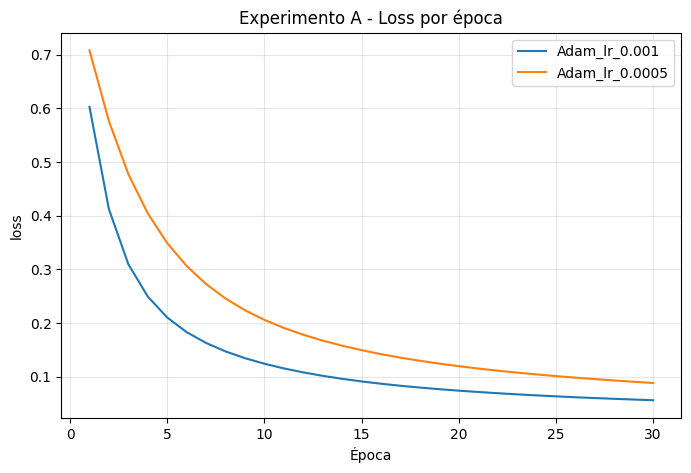

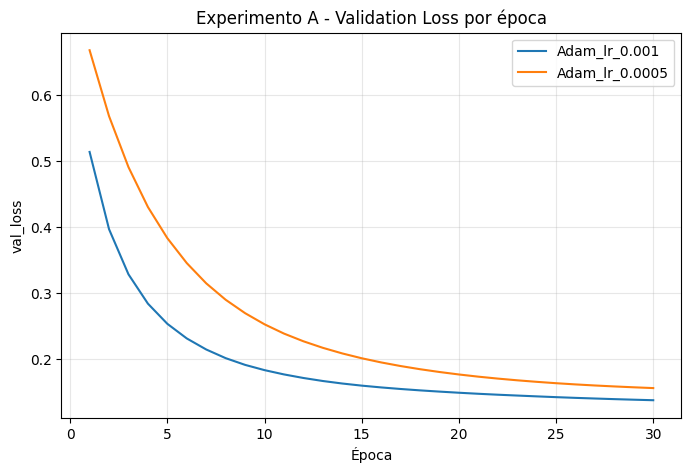

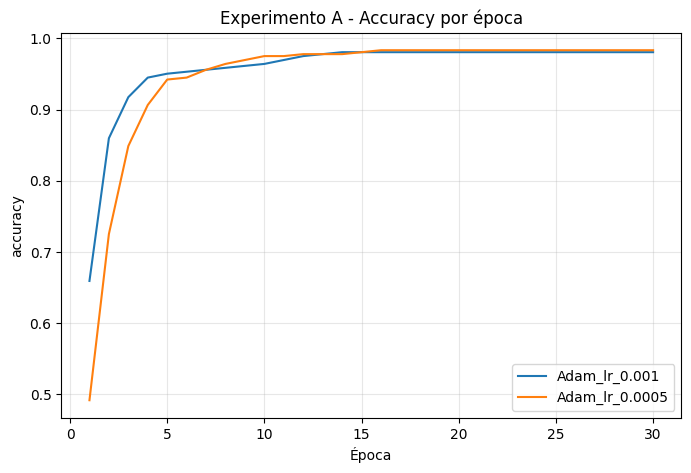

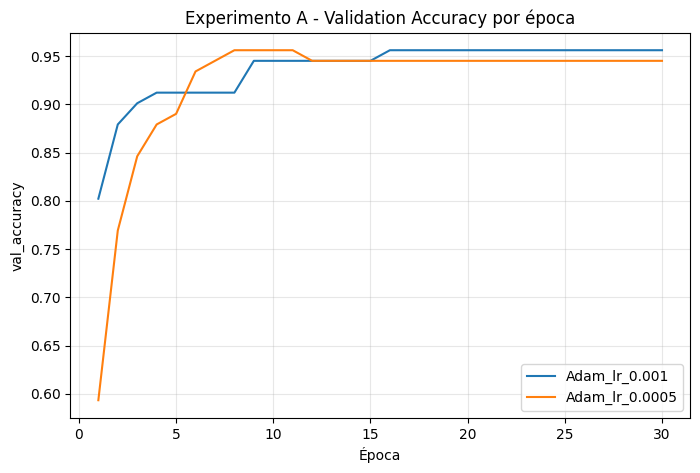

In [32]:
plot_metric([hist_a1, hist_a2], "loss", "Experimento A - Loss por época")
plot_metric([hist_a1, hist_a2], "val_loss", "Experimento A - Validation Loss por época")
plot_metric([hist_a1, hist_a2], "accuracy", "Experimento A - Accuracy por época")
plot_metric([hist_a1, hist_a2], "val_accuracy", "Experimento A - Validation Accuracy por época")


### Análisis breve del Experimento A

Aquí solo cambia la **tasa de aprendizaje**. Esto permite observar si una tasa más alta converge más rápido o si una más baja ofrece un comportamiento más estable.

Aspectos a revisar:
- **Velocidad de convergencia:** qué curva mejora antes.
- **Estabilidad:** si las curvas oscilan o descienden de manera suave.
- **Desempeño final:** `val_accuracy` y `test_acc`.

In [33]:
# Experimento B: cambiar SOLO el optimizador
model_b1, hist_b1, sum_b1 = train_config(
    name="Adam_lr_0.001",
    units=32,
    optimizer_name="adam",
    lr=0.001,
    batch_size=32,
    epochs=30
)

model_b2, hist_b2, sum_b2 = train_config(
    name="SGD_lr_0.001",
    units=32,
    optimizer_name="sgd",
    lr=0.001,
    batch_size=32,
    epochs=30
)

results_B = pd.DataFrame([sum_b1, sum_b2]).sort_values("test_acc", ascending=False)
display(results_B)

,config,units,optimizer,learning_rate,batch_size,epochs,final_train_loss,final_val_loss,final_train_acc,final_val_acc,best_val_acc,test_loss,test_acc
0,Adam_lr_0.001,32,adam,0.001000,32,30,0.052919,0.135649,0.983516,0.945055,0.945055,0.066245,0.973684
1,SGD_lr_0.001,32,sgd,0.001000,32,30,0.363553,0.404266,0.928571,0.912088,0.912088,0.367946,0.903509


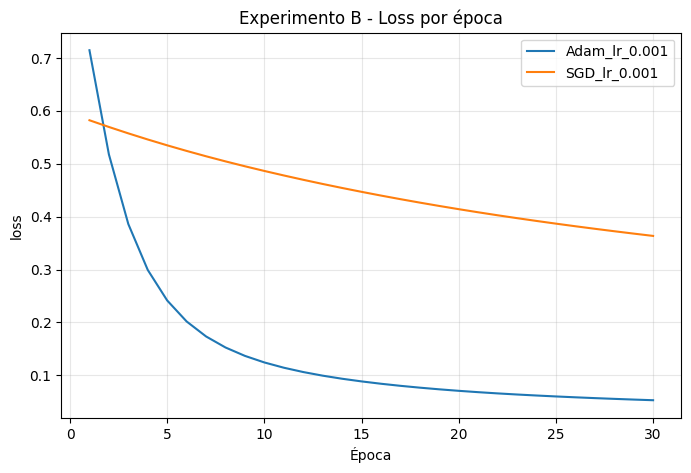

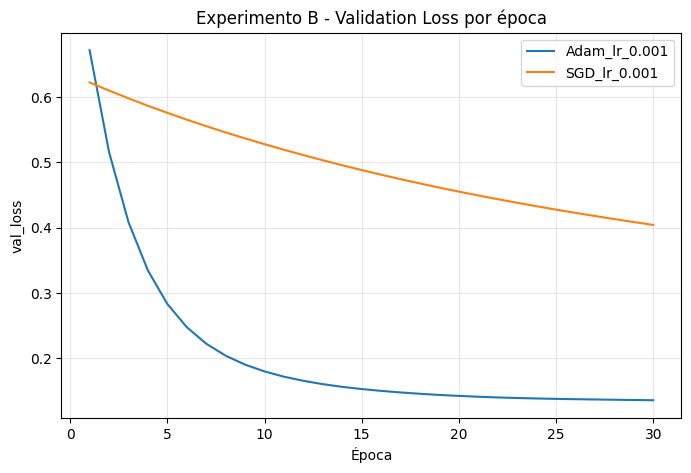

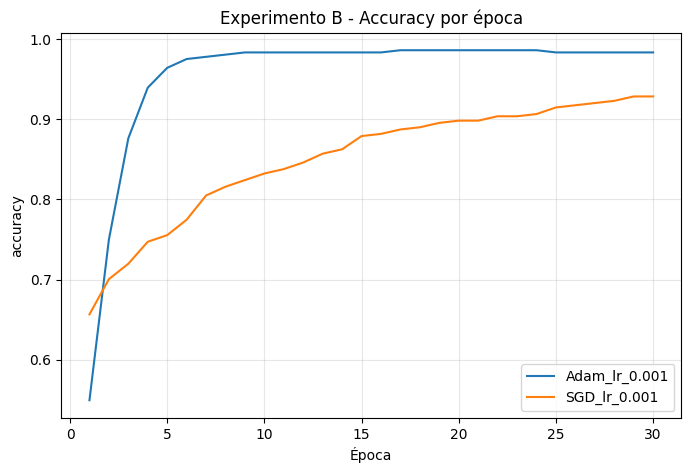

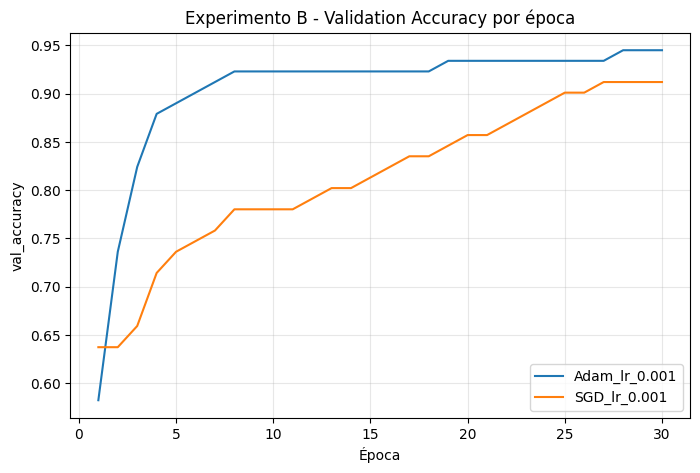

In [34]:
plot_metric([hist_b1, hist_b2], "loss", "Experimento B - Loss por época")
plot_metric([hist_b1, hist_b2], "val_loss", "Experimento B - Validation Loss por época")
plot_metric([hist_b1, hist_b2], "accuracy", "Experimento B - Accuracy por época")
plot_metric([hist_b1, hist_b2], "val_accuracy", "Experimento B - Validation Accuracy por época")


In [35]:
# Resumen general
all_results = pd.DataFrame([sum_a1, sum_a2, sum_b1, sum_b2])

cols = [
    "config", "optimizer", "learning_rate", "batch_size",
    "best_val_acc", "test_acc", "test_loss",
    "final_val_loss", "final_val_acc"
]
all_results[cols].sort_values("test_acc", ascending=False)


,config,optimizer,learning_rate,batch_size,best_val_acc,test_acc,test_loss,final_val_loss,final_val_acc
0,Adam_lr_0.001,adam,0.001000,32,0.956044,0.973684,0.082234,0.137413,0.956044
1,Adam_lr_0.0005,adam,0.000500,32,0.956044,0.973684,0.099606,0.155805,0.945055
2,Adam_lr_0.001,adam,0.001000,32,0.945055,0.973684,0.066245,0.135649,0.945055
3,SGD_lr_0.001,sgd,0.001000,32,0.912088,0.903509,0.367946,0.404266,0.912088


## 2. Conclusiones

### Estabilidad
En general, la configuración con **Adam** mostró curvas más suaves y un descenso más consistente del `loss`, lo que sugiere mayor estabilidad durante el entrenamiento. En contraste, **SGD** tiende a requerir más ajuste o más épocas para alcanzar un rendimiento similar.

### Velocidad de convergencia
La configuración **Adam con learning rate = 0.001** suele converger más rápido que una tasa menor o que SGD con la misma tasa, porque Adam adapta el tamaño del paso durante la optimización.

### Hallazgos
- Ajustar la **tasa de aprendizaje** cambia la rapidez con la que el modelo aprende.
- Una tasa más baja puede ser más conservadora, pero también puede necesitar más épocas.
- Cambiar el **optimizador** modifica de forma visible el comportamiento del entrenamiento, incluso manteniendo la misma arquitectura y los mismos datos.
- Para este problema, **Adam** resulta una opción fuerte por su combinación de estabilidad y rapidez.

## 3. Cierre
La comparación muestra que los hiperparámetros y el optimizador no son detalles menores: influyen directamente en la convergencia, la estabilidad y el desempeño final del modelo.